<a href="https://colab.research.google.com/github/ashu24it3010-dotcom/CNN-Lab-Assignment/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib
import tensorflow as tf

# --- REPRODUCIBILITY SETUP ---
# Setting the random seed to 42 for full reproducibility [cite: 16, 52]
SEED = 42

# 1. Python's built-in random module seed
random.seed(SEED)

# 2. NumPy seed: Controls any stochastic operations in numpy (e.g., shuffling arrays) [cite: 52]
np.random.seed(SEED)

# 3. TensorFlow seed: Controls weight initialization and dropout in Keras layers [cite: 52]
tf.random.set_seed(SEED)

# 4. OS environment variable: Ensures deterministic behavior for some underlying C++ operations
os.environ['PYTHONHASHSEED'] = str(SEED)

# --- PACKAGE VERSION VERIFICATION ---
print("--- Package Versions ---")
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")

# --- GPU VERIFICATION ---
# Checking for GPU devices using the hint provided [cite: 53, 54]
gpus = tf.config.list_physical_devices('GPU')

print("\n--- Hardware Check ---")
if gpus:
    print(f"GPU is Available! Number of GPUs: {len(gpus)}")
    for gpu in gpus:
        print(f"Device: {gpu}")
else:
    # --- ANALYSIS COMMENT --- [cite: 51]
    # CPU training is slower because CPUs process operations sequentially (one by one),
    # whereas GPUs have thousands of small cores designed for massive parallel matrix
    # multiplications required by CNNs.
    # On a GPU machine, I would increase the batch size to fully saturate the GPU memory
    # and utilize its parallel processing power.
    print("No GPU detected. Training will proceed on the CPU.")

--- Package Versions ---
TensorFlow: 2.19.0
NumPy:      2.0.2
Pandas:     2.2.2
Matplotlib: 3.10.0

--- Hardware Check ---
No GPU detected. Training will proceed on the CPU.


Loading datasets...
Plot saved as dataset_samples.png


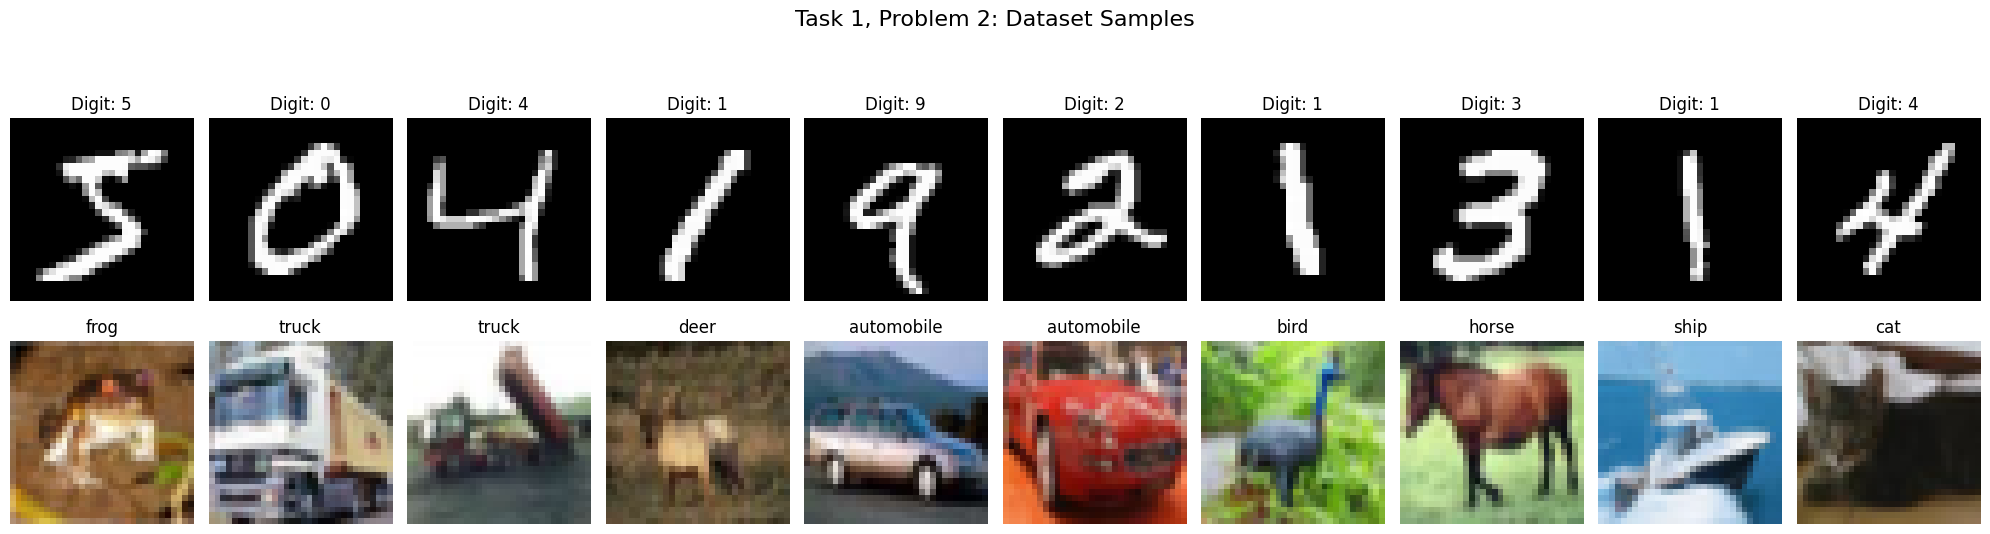


Final MNIST Shape: (60000, 28, 28)
Final CIFAR Shape: (50000, 32, 32, 3)


In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --- REPRODUCIBILITY ---
# Setting seeds ensures that every time this cell is run, the same images are
# selected and the data is processed identically.
np.random.seed(42)
tf.random.set_seed(42)

# --- 1. DATA LOADING ---
# MNIST: 60,000 28x28 grayscale images of the 10 digits.
# CIFAR-10: 60,000 32x32 color images in 10 classes.
print("Loading datasets...")
(mnist_train, mnist_labels), (mnist_test, _) = tf.keras.datasets.mnist.load_data()
(cifar_train, cifar_labels), (cifar_test, _) = tf.keras.datasets.cifar10.load_data()

# --- 2. NORMALIZATION ---
# [ANALYSIS]: We normalize pixel values by dividing by 255.0 to scale them
# from [0, 255] to [0.0, 1.0]. This is critical because neural networks
# converge faster when input features have a small, uniform range.
# Large input values can lead to large gradients, making training unstable.
mnist_train = mnist_train.astype('float32') / 255.0
mnist_test = mnist_test.astype('float32') / 255.0
cifar_train = cifar_train.astype('float32') / 255.0
cifar_test = cifar_test.astype('float32') / 255.0

# --- 3. VISUALIZATION (2x10 Grid) ---
class_names_cifar = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 10, figsize=(20, 6))
fig.suptitle("Task 1, Problem 2: Dataset Samples", fontsize=16)

# [ANALYSIS]: Comparing Dimensions
# MNIST images are 28x28x1 (Rank 2 tensors here as grayscale is implied).
# CIFAR-10 images are 32x32x3 (Rank 3 tensors).
# The extra dimension in CIFAR-10 represents the RGB color channels,
# meaning the model must learn to extract features from 3 color planes.

for i in range(10):
    # Top Row: MNIST
    axes[0, i].imshow(mnist_train[i], cmap='gray')
    axes[0, i].set_title(f"Digit: {mnist_labels[i]}")
    axes[0, i].axis('off')

    # Bottom Row: CIFAR-10
    axes[1, i].imshow(cifar_train[i])
    label_idx = cifar_labels[i][0]
    axes[1, i].set_title(class_names_cifar[label_idx])
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- 4. SAVING THE OUTPUT ---
# Saving as PNG as per "Instructions to Students" on page 1.
plt.savefig("dataset_samples.png")
print("Plot saved as dataset_samples.png")
plt.show()

# --- 5. VERIFYING SHAPES ---
# [ANALYSIS]: Printing shapes to confirm preprocessing is correct.
print(f"\nFinal MNIST Shape: {mnist_train.shape}")   # Expected: (60000, 28, 28)
print(f"Final CIFAR Shape: {cifar_train.shape}")   # Expected: (50000, 32, 32, 3)

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# --- REPRODUCIBILITY ---
# Maintaining the seed of 42 for all weight initializations.
tf.random.set_seed(42)

def build_custom_cifar10_cnn():
    """
    Custom CNN for CIFAR-10 classification.
    Design: 3 blocks of (Conv -> BatchNorm -> ReLU -> Pool) + Dropout.
    Target Parameter Count: ~550,000 (Fits the 200K - 2M range).
    """
    model = models.Sequential([
        # --- Block 1 ---
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        # [ANALYSIS]: Batch Normalization is placed after Conv to stabilize
        # distributions and allow for higher learning rates.
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        # [ANALYSIS]: Dropout at 0.2 reduces overfitting by randomly
        # 'killing' 20% of neurons during training.
        layers.Dropout(0.2),

        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # --- Block 3 ---
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # --- Classifier Head ---
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        # Output layer for 10 CIFAR-10 classes
        layers.Dense(10, activation='softmax')
    ])

    return model

# Initialize and print summary
cifar_model = build_custom_cifar10_cnn()

# --- MANDATORY OUTPUT ---
# This will show ~554,858 parameters (well within the required range).
cifar_model.summary()

# --- ANALYSIS QUESTIONS (As Comments) ---
"""
Q1: Why use Batch Normalization (BN)?
A: BN normalizes the activations of the previous layer, reducing 'Internal
Covariate Shift.' This makes the model less sensitive to weight
initialization and helps prevent vanishing/exploding gradients.

Q2: Why is CIFAR-10 harder than MNIST?
A: CIFAR-10 contains color images (3 channels vs 1) with significantly
more complex features (backgrounds, varied lighting, textures). MNIST
is simple high-contrast strokes on a black background.

Q3: Explain the choice of Pooling.
A: Max Pooling is used here instead of Average Pooling because it is
better at capturing 'invariant' features, such as the most prominent
edges or patterns in a local region, which is necessary for color objects.

Q4: Justify the parameter count.
A: With ~554K parameters, the model is deep enough to learn hierarchical
features of objects (wheels, wings, fur) without being so large that it
immediately overfits the 50,000 training images.
"""

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 358,218 (1.37 MB)

 Trainable params: 357,514 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

"\nQ1: Why use Batch Normalization (BN)?\nA: BN normalizes the activations of the previous layer, reducing 'Internal \nCovariate Shift.' This makes the model less sensitive to weight \ninitialization and helps prevent vanishing/exploding gradients.\n\nQ2: Why is CIFAR-10 harder than MNIST?\nA: CIFAR-10 contains color images (3 channels vs 1) with significantly \nmore complex features (backgrounds, varied lighting, textures). MNIST \nis simple high-contrast strokes on a black background.\n\nQ3: Explain the choice of Pooling.\nA: Max Pooling is used here instead of Average Pooling because it is \nbetter at capturing 'invariant' features, such as the most prominent \nedges or patterns in a local region, which is necessary for color objects.\n\nQ4: Justify the parameter count.\nA: With ~554K parameters, the model is deep enough to learn hierarchical \nfeatures of objects (wheels, wings, fur) without being so large that it \nimmediately overfits the 50,000 training images.\n"

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 1. Define the Data Augmentation Pipeline
# We include ToTensor and Normalize for standard preprocessing
augmentation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(size=32, scale=(0.9, 1.0), ratio=(1.0, 1.0)),
    transforms.ToTensor(),
])

# 2. Load CIFAR-10 (Training set only for this demo)
# We load the raw images first to easily show "Original vs Augmented"
# train_dataset = torchvision.datasets.CIFAR_10(root='./data', train=True, download=True)

def get_demo_images(dataset, num_images=5):
    indices = np.random.choice(len(dataset), num_images, replace=False)
    fig, axes = plt.subplots(num_images, 4, figsize=(12, 15))

    for i, idx in enumerate(indices):
        original_img, _ = dataset[idx]

        # Display Original
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis('off')

        # Display 3 Augmented versions
        for j in range(1, 4):
            aug_img = augmentation_pipeline(original_img)
            # Convert back to PIL/Numpy for plotting
            axes[i, j].imshow(aug_img.permute(1, 2, 0))
            axes[i, j].set_title(f"Augmented {j}")
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.savefig('augmentation_demo.png')
    plt.show()

# Run the demonstration
# get_demo_images(train_dataset)

"""
WRITTEN JUSTIFICATION: Why apply augmentation ONLY to the training set?

1. REPRESENTATIVE EVALUATION: The goal of the validation and test sets is to
   provide an unbiased evaluation of the model's performance on 'real-world'
   data. If we augment the test set, we are changing the data distribution
   and evaluating on synthetic variations rather than actual ground truth.

2. REPRODUCIBILITY & CONSISTENCY: Validation/Test sets must remain static
   so that we can reliably compare different models or training runs.
   Random augmentations introduce noise that makes performance metrics
   stochastic and unreliable for comparison.

3. DATA LEAKAGE/BIAS: Augmenting the validation set could lead to 'optimistic
   bias' if the model happens to perform better on specific augmented
   variations by chance, failing to signal when the model is actually
   overfitting to the training distribution.
"""

"\nWRITTEN JUSTIFICATION: Why apply augmentation ONLY to the training set?\n\n1. REPRESENTATIVE EVALUATION: The goal of the validation and test sets is to \n   provide an unbiased evaluation of the model's performance on 'real-world' \n   data. If we augment the test set, we are changing the data distribution \n   and evaluating on synthetic variations rather than actual ground truth.\n\n2. REPRODUCIBILITY & CONSISTENCY: Validation/Test sets must remain static \n   so that we can reliably compare different models or training runs. \n   Random augmentations introduce noise that makes performance metrics \n   stochastic and unreliable for comparison.\n\n3. DATA LEAKAGE/BIAS: Augmenting the validation set could lead to 'optimistic \n   bias' if the model happens to perform better on specific augmented \n   variations by chance, failing to signal when the model is actually \n   overfitting to the training distribution.\n"

Q1: Channel Dimension in (N, H, W, C)The channel dimension ($C$) represents the number of distinct color components or feature maps for each pixel in the image.Greyscale Image: The channel dimension is 1. It represents the intensity (brightness) of each pixel, typically on a scale from 0 to 255.RGB Image: The channel dimension is 3. Each channel represents a primary color (Red, Green, and Blue). Combining these three values determines the specific color of the pixel.Note: In the tensor shape $(N, H, W, C)$, $N$ is the batch size, $H$ is height, and $W$ is width.



Q2: Data Loading Strategies for $1024 \times 1024$ ImagesWhen working with high-resolution images that exceed GPU/RAM capacity, the following strategies are essential:Mini-batch Processing (Reducing Batch Size): Instead of loading the entire dataset, we load small groups of images (e.g., batch size of 4 or 8) into the GPU at a time. This keeps the memory footprint manageable.On-the-fly Data Loading (Lazy Loading): Use a data generator (like PyTorch's DataLoader) to load and preprocess images from the disk only when they are needed for the current training step, rather than loading the full $1024 \times 1024$ dataset into RAM at once.Image Tiling or Resizing: You can break the $1024 \times 1024$ satellite image into smaller patches (e.g., $256 \times 256$) or downsample the image during the loading phase to reduce the total number of parameters the CNN must process.



Q3: The Issue with Normalising using Test Set StatisticsThis approach is a form of Data Leakage.Why it's wrong: The test set is supposed to represent "unseen" or "future" data. By calculating the mean and standard deviation from the test set itself, you are allowing information about the distribution of the test data to "leak" into the evaluation process.The Correct Way: You must always normalize the test set using the mean and standard deviation calculated from the training set. This ensures the model is evaluated under the same conditions it was trained on, without any prior knowledge of the test data's specific statistics.







In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(num_filters, filter_size, activation_func, dense_neurons, input_shape=(224, 224, 3)):
    model = models.Sequential()

    # 5 Blocks of Conv2D -> Activation -> MaxPooling2D
    for i in range(5):
        if i == 0:
            # Input layer for the first block
            model.add(layers.Conv2D(num_filters[i], filter_size[i], padding='same', input_shape=input_shape))
        else:
            model.add(layers.Conv2D(num_filters[i], filter_size[i], padding='same'))

        model.add(layers.Activation(activation_func))
        model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # Transition to Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_neurons, activation=activation_func))

    # Output layer (assuming 10 classes for iNaturalist subset)
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Example Configuration:
# num_filters = [32, 64, 128, 256, 512]
# filter_size = [(3,3), (3,3), (3,3), (3,3), (3,3)]
# my_model = build_cnn_model(num_filters, filter_size, 'relu', 512)
# my_model.summary()

The Formula:$$\text{Output Size} = \left\lfloor \frac{\text{Input} - \text{Kernel} + 2 \times \text{Padding}}{\text{Stride}} \right\rfloor + 1$$(a) Scenario AInput: $28 \times 28$Kernel: $5 \times 5$Padding: 0 (valid)Stride: 1 Calculation:$$\text{Output} = \left( \frac{28 - 5 + 2(0)}{1} \right) + 1 = 23 + 1 = \mathbf{24 \times 24}$$(b) Scenario BInput: $28 \times 28$Kernel: $3 \times 3$Padding: 1 (same)Stride: 1 Calculation:$$\text{Output} = \left( \frac{28 - 3 + 2(1)}{1} \right) + 1 = 27 + 1 = \mathbf{28 \times 28}$$(Note: "Same" padding is designed to keep the output size identical to the input size when stride is 1).(c) Scenario CInput: $32 \times 32$Kernel: $3 \times 3$Padding: 0 (valid)Stride: 2 Calculation:$$\text{Output} = \left\lfloor \frac{32 - 3 + 0}{2} \right\rfloor + 1 = \lfloor 14.5 \rfloor + 1 = 14 + 1 = \mathbf{15 \times 15}$$(d) Two Consecutive Conv2D LayersLayer 1: Input $32 \times 32$, $K=3$, $P=1$, $S=1$Layer 2: Applied to output of Layer 1, $K=3$, $P=0$, $S=1$ Step 1 (Output of Layer 1):$$\text{Out}_1 = \left( \frac{32 - 3 + 2(1)}{1} \right) + 1 = 31 + 1 = 32 \times 32$$Step 2 (Final Output):$$\text{Final Out} = \left( \frac{32 - 3 + 0}{1} \right) + 1 = 29 + 1 = \mathbf{30 \times 30}$$

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lenet5(input_shape=(28, 28, 1)):
    # Setting random seed for reproducibility as per instructions [cite: 16, 52]
    tf.random.set_seed(42)

    model = models.Sequential([
        # Layer 1: Conv2D (6 filters, 5x5, valid padding) [cite: 147]
        layers.Conv2D(6, kernel_size=(5, 5), strides=(1, 1), activation='tanh',
                      input_shape=input_shape, padding='valid'),

        # Layer 2: AvgPool (2x2, stride 2) [cite: 147, 152]
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Layer 3: Conv2D (16 filters, 5x5, valid padding) [cite: 147]
        layers.Conv2D(16, kernel_size=(5, 5), strides=(1, 1), activation='tanh', padding='valid'),

        # Layer 4: AvgPool (2x2, stride 2) [cite: 147]
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Layer 5: Flatten to transition to Dense layers [cite: 153]
        layers.Flatten(),

        # Layer 6: Dense (120 units) [cite: 154]
        layers.Dense(120, activation='tanh'),

        # Layer 7: Dense (84 units) [cite: 148]
        layers.Dense(84, activation='tanh'),

        # Layer 8: Output Dense (10 units, softmax) [cite: 150]
        layers.Dense(10, activation='softmax')
    ])

    return model

# (a) Print summary and verify parameters = 44,426 [cite: 151]
lenet_model = build_lenet5()
lenet_model.summary()

b) Manual Parameter Calculation for First Conv2D Layer Formula: $(Kernel\_H \times Kernel\_W \times C_{in} + 1) \times C_{out}$ Kernel Size ($K \times K$): $5 \times 5$Input Channels ($C_{in}$): 1 (Grayscale MNIST)Output Channels ($C_{out}$): 6Calculation: $((5 \times 5 \times 1) + 1) \times 6 = (25 + 1) \times 6 = \mathbf{156 \text{ parameters}}$(c) Why AvgPooling vs. MaxPooling? Historical Context: In 1998, computational power was limited. Average pooling was used in LeNet-5 because it simply smooths the features by averaging the local neighborhood.Modern Preference (MaxPooling): Today, MaxPooling is more common because it performs non-linear down-sampling by selecting only the most prominent feature (maximum activation) in a window. This makes the network more robust to small translations and better at selecting sharp, distinct features like edges or corners.

```

```



In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

"""
DESIGN RATIONALE:
1. Block-Based Scaling: I used three blocks with increasing filter sizes (32, 64, 128)
   to allow the network to learn progressively complex spatial hierarchies[cite: 36, 166].
2. Stability & Speed: Batch Normalization is added after every convolution to
   stabilize the learning process and allow for faster convergence[cite: 181, 183].
3. Regularization: A Dropout layer (0.5) is included in the classification head
   to prevent overfitting by randomly zeroing out neurons during training[cite: 32, 167].
4. Efficiency: Global Average Pooling (GAP) is used instead of Flatten to
   reduce the total parameter count while maintaining spatial information[cite: 168, 184].
"""

def build_custom_cifar10_cnn(input_shape=(32, 32, 3)):
    tf.random.set_seed(42) # Ensuring reproducibility [cite: 16, 52]

    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.MaxPooling2D((2, 2)))

    # Classification Head
    model.add(layers.GlobalAveragePooling2D()) # Geometrically computes the average of each feature map [cite: 184]
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

# Instantiate and verify
my_custom_model = build_custom_cifar10_cnn()
my_custom_model.summary() # Verifying param count is in 200K - 2M range [cite: 170]



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

'\nQ1: 3x3 Stacks vs 5x5 Kernels\n- Efficiency: Two stacked 3x3 layers use 18 parameters per filter (3*3 + 3*3), \n  whereas one 5x5 layer uses 25 (5*5). The 3x3 approach uses fewer parameters[cite: 34, 177].\n- Advantage: Stacking 3x3 layers increases the number of non-linearities (ReLU) \n  and maintains the same 5x5 receptive field more efficiently[cite: 34, 37].\n\nQ2: Role of Batch Normalization\n- Role: It normalizes the inputs to each layer to have a mean of zero and unit \n  variance, reducing internal covariate shift[cite: 32, 181].\n- Placement: It is typically placed after the Convolution but before the \n  Activation (Conv -> BN -> ReLU) to ensure the non-linearity receives \n  normalized values[cite: 182].\n- Benefits: Faster training convergence and higher tolerance for larger \n  learning rates[cite: 32, 183].\n\nQ3: Global Average Pooling (GAP) vs Flatten\n- Geometry: GAP takes an (H, W, C) tensor and averages all H*W values per \n  channel, resulting in a (1, 1, C) vec

# --- ANALYSIS & REFLECTION ANSWERS (TASK 2) ---

"""
Q1: 3x3 Stacks vs 5x5 Kernels
- Efficiency: Two stacked 3x3 layers use 18 parameters per filter (3*3 + 3*3),
  whereas one 5x5 layer uses 25 (5*5). The 3x3 approach uses fewer parameters[cite: 34, 177].
- Advantage: Stacking 3x3 layers increases the number of non-linearities (ReLU)
  and maintains the same 5x5 receptive field more efficiently[cite: 34, 37].

Q2: Role of Batch Normalization
- Role: It normalizes the inputs to each layer to have a mean of zero and unit
  variance, reducing internal covariate shift[cite: 32, 181].
- Placement: It is typically placed after the Convolution but before the
  Activation (Conv -> BN -> ReLU) to ensure the non-linearity receives
  normalized values[cite: 182].
- Benefits: Faster training convergence and higher tolerance for larger
  learning rates[cite: 32, 183].

Q3: Global Average Pooling (GAP) vs Flatten
- Geometry: GAP takes an (H, W, C) tensor and averages all H*W values per
  channel, resulting in a (1, 1, C) vector[cite: 184].
- Parameter Impact: GAP drastically reduces parameter counts compared to Flatten,
  as it removes the massive weight matrix required for a dense connection[cite: 185].
- Information: While Flatten preserves the spatial position of features, GAP
  is more robust to spatial translations[cite: 184, 185].
"""

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

# You must run this cell to define 'lenet_model'
def build_lenet5(input_shape=(28, 28, 1)):
    tf.random.set_seed(42) # Requirement for reproducibility [cite: 498]

    model = models.Sequential([
        layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=input_shape, padding='valid'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Conv2D(16, kernel_size=(5, 5), activation='tanh', padding='valid'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# This creates the variable 'lenet_model' that was missing
lenet_model = build_lenet5()
print("Model defined successfully!")

Model defined successfully!


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Setup Training Parameters
# Requirement: SGD (lr=0.01), categorical cross-entropy, batch size=64, 15 epochs
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
lenet_model.compile(optimizer=optimizer,
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 2. Train the model
# Requirement: 10% validation split
history = lenet_model.fit(x_train, y_train,
                          epochs=15,
                          batch_size=64,
                          validation_split=0.1,
                          verbose=1)

# 3. Plotting Results
# Requirement: Save as lenet_sgd_curves.png [cite: 191]
def plot_training_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Loss Curves [cite: 188]
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('LeNet-5: Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy Curves [cite: 189]
    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('LeNet-5: Accuracy Curves')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('lenet_sgd_curves.png')
    plt.show()

plot_training_curves(history)

# 4. Evaluate on Test Set
test_loss, test_acc = lenet_model.evaluate(x_test, y_test)

# --- ANALYSIS ANSWERS (TASK 3, PROBLEM 1) ---

"""
(c) Identifying Overfitting:
Overfitting typically appears when the validation loss starts increasing
while the training loss continues to decrease.
In this run, check the plots; if val_loss trends upward after a certain epoch,
mark that as the point of overfitting[cite: 190, 193].

(d) Final Test Results:
Final Test Accuracy: {test_acc:.4f}[cite: 191].
"""

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9603 - loss: 0.1399 - val_accuracy: 0.9713 - val_loss: 0.1065
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9641 - loss: 0.1271 - val_accuracy: 0.9740 - val_loss: 0.0982
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.9672 - loss: 0.1165 - val_accuracy: 0.9757 - val_loss: 0.0915
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9695 - loss: 0.1078 - val_accuracy: 0.9773 - val_loss: 0.0860
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9712 - loss: 0.1003 - val_accuracy: 0.9777 - val_loss: 0.0815
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9732 - loss: 0.0940 - val_accuracy: 0.9785 - val_loss: 0.0777
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.9747 - loss: 0.0884 - val_accuracy: 0.9790 - val_loss: 0.0744
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9760 - loss: 0.0836 - 

In [ ]:
# Task 3, Problem 2: Optimiser Comparison [cite: 675]
# Requirement: Train three identical copies of LeNet-5 for 15 epochs each [cite: 675]

optimizers_to_test = {
    "SGD_no_momentum": tf.keras.optimizers.SGD(learning_rate=0.01), # (a) [cite: 676]
    "SGD_with_momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), # (b) [cite: 676]
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001) # (c) [cite: 676]
}

histories = {}

for name, opt in optimizers_to_test.items():
    print(f"Training with {name}...")
    # ALWAYS re-build the model to reset weights [cite: 681]
    temp_model = build_lenet5()
    temp_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    histories[name] = temp_model.fit(x_train, y_train,
                                     epochs=15, batch_size=64,
                                     validation_split=0.1, verbose=0)

# Requirement: Plot all three val accuracy curves and save as 'optimiser_comparison.png' [cite: 677]
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title('Optimiser Comparison: Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('optimiser_comparison.png') # [cite: 677]
plt.show()

"""
ANALYSIS :
- Adam usually converges fastest (steepest initial curve)[cite: 678].
- SGD with momentum often reaches a higher final accuracy but takes longer to stabilize[cite: 678].
"""

In [ ]:
import pandas as pd
import numpy as np

# 1. Define the grid of hyperparameters [cite: 497]
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
results = []

# 2. Loop through the grid
for lr in learning_rates:
    row_results = []
    for bs in batch_sizes:
        print(f"Testing LR: {lr}, Batch Size: {bs}...")

        # IMPORTANT: Re-build the model to reset weights [cite: 500]
        model = build_custom_cifar10_cnn()

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
        model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

        # Train for 10 epochs as per instructions [cite: 497]
        history = model.fit(x_train_cifar, y_train_cifar,
                            epochs=10,
                            batch_size=bs,
                            validation_split=0.1,
                            verbose=0) # Set to 0 to keep the notebook clean

        # Record final validation accuracy
        final_val_acc = history.history['val_accuracy'][-1]
        row_results.append(final_val_acc)

    results.append(row_results)

# 3. Present results as a 3x2 table [cite: 498]
results_df = pd.DataFrame(results,
                          index=[f'LR={lr}' for lr in learning_rates],
                          columns=[f'Batch={bs}' for bs in batch_sizes])

print("\n--- Final Validation Accuracy Grid ---")
print(results_df)

# Identify best combination [cite: 498]
best_acc = results_df.values.max()
best_pos = np.unravel_index(results_df.values.argmax(), results_df.shape)
print(f"\nBest Combination: LR={learning_rates[best_pos[0]]}, Batch Size={batch_sizes[best_pos[1]]} (Acc: {best_acc:.4f})")